In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

class RealSpaceMagneticPolaron:
    def __init__(self, t, J_0, J_e, s, gamma=1.0):
        self.t = float(t)
        self.J_0 = float(J_0)
        self.J_e = float(J_e)
        self.s = float(s)
        self.gamma = float(gamma)

    def denominator(self, z, K):
        z = np.asarray(z, dtype=np.complex128)
        K = np.asarray(K, dtype=float)
        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0
        alpha = z - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * self.s
        disc = alpha**2 - 4.0 * A_plus * A_minus
        sqrt_disc = np.sqrt(disc + 0j)
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = np.where(np.abs(rho1) < np.abs(rho2), rho1, rho2)
        beta = z - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * (self.s - 1.0)
        g2 = (self.gamma * self.J_e)**2 * self.s / 2.0
        Sigma = g2 / (beta + 2.0 * A_minus * rho)
        return z + 2.0 * self.t * np.cos(K) + 0.5 * self.J_e * self.s - Sigma

    def denominator_real_below_continuum(self, omega, K):
        """
        Evaluate D(omega, K) on the real axis, ASSUMING omega is below the
        spin-polaron continuum so disc > 0 and D is purely real.
        Returns a real float. Use this for brentq.
        """
        omega = float(omega)
        K = float(K)
        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0
        alpha = omega - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * self.s
        disc = alpha**2 - 4.0 * A_plus * A_minus
        # Below continuum: disc is real and positive
        disc_real = disc.real
        if disc_real < 0:
            disc_real = 0.0  # at the edge
        sqrt_disc = np.sqrt(disc_real)
        # rho candidates (A_minus is complex but for real omega below continuum,
        # A+A- is real, so alpha^2 - 4A+A- is real, and rho is real)
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = rho1 if abs(rho1) < abs(rho2) else rho2
        beta = omega - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * (self.s - 1.0)
        g2 = (self.gamma * self.J_e)**2 * self.s / 2.0
        Sigma = g2 / (beta + 2.0 * A_minus * rho)
        result = omega + 2.0 * self.t * np.cos(K) + 0.5 * self.J_e * self.s - Sigma
        return result.real

    def sp_continuum_edge(self, K):
        """
        Lower edge of the spin-polaron continuum at momentum K.
        This is where disc = alpha^2 - 4 A+ A- = 0.
        The continuum is the electron-magnon scattering states:
           E(K,q) = -2t cos(K-q) + 2 J0 s (1 - cos q) + Je s / 2
        Minimized over magnon momentum q.
        """
        K = float(K)
        q_grid = np.linspace(-np.pi, np.pi, 5000)
        E_vals = (-2.0 * self.t * np.cos(K - q_grid)
                  + 2.0 * self.J_0 * self.s * (1.0 - np.cos(q_grid))
                  + 0.5 * self.J_e * self.s)
        return np.min(E_vals)

    def G_minus(self, z, K):
        return 1.0 / self.denominator(z, K)

    def spectral_weight(self, K, omega, eta=2e-2):
        z = omega + 1j * eta
        return -np.imag(self.G_minus(z, K)) / np.pi


def extract_lowest_spin_polaron_band(pol, p_grid, wmin=-8.0, padding=1e-8):
    """
    Exact pole extraction.
    1. For each p, compute the spin-polaron continuum edge E_cont(p).
    2. Search for the pole of D(omega, p) = 0 in [wmin, E_cont(p) - padding].
    3. Use a coarse scan + brentq refinement.
    """
    n_p = len(p_grid)
    E_sp = np.full(n_p, np.nan, dtype=float)

    # Step 1: continuum edges (vectorized over q, looped over p)
    E_cont = np.array([pol.sp_continuum_edge(p) for p in p_grid])

    # Step 2: for each p, find the pole below E_cont
    for j, p in enumerate(p_grid):
        w_lo = wmin
        w_hi = E_cont[j] - padding

        if w_hi <= w_lo:
            continue

        # Coarse scan
        n_scan = 2000
        w_scan = np.linspace(w_lo, w_hi, n_scan)
        D_scan = np.array([pol.denominator_real_below_continuum(w, p) for w in w_scan])

        # Find sign changes
        sign_changes = np.where(np.diff(np.signbit(D_scan)))[0]

        if len(sign_changes) == 0:
            # Adaptive refinement near the continuum edge
            # Use geometrically spaced points to resolve arbitrarily small binding
            found_fine = False
            for depth in range(8):  # each level 10x finer
                width = 0.5 * (0.1 ** depth)
                w_lo_fine = max(w_lo, w_hi - width)
                if w_hi - w_lo_fine < 1e-15:
                    break
                w_scan_fine = np.linspace(w_lo_fine, w_hi, 2000)
                D_scan_fine = np.array([pol.denominator_real_below_continuum(w, p)
                                        for w in w_scan_fine])
                sign_changes_fine = np.where(np.diff(np.signbit(D_scan_fine)))[0]
                if len(sign_changes_fine) > 0:
                    roots = []
                    for i in sign_changes_fine:
                        try:
                            root = brentq(
                                lambda w: pol.denominator_real_below_continuum(w, p),
                                w_scan_fine[i], w_scan_fine[i+1], xtol=1e-14)
                            roots.append(root)
                        except:
                            pass
                    if roots:
                        E_sp[j] = min(roots)
                        found_fine = True
                    break
            if not found_fine:
                continue

        # Refine all brackets, take the lowest
        roots = []
        for i in sign_changes:
            try:
                root = brentq(lambda w: pol.denominator_real_below_continuum(w, p),
                              w_scan[i], w_scan[i+1], xtol=1e-14)
                roots.append(root)
            except:
                pass
        if roots:
            E_sp[j] = min(roots)

    return E_sp, E_cont


def wrap_to_bz(x):
    return (x + np.pi) % (2.0 * np.pi) - np.pi


def spin_polaron_hole_continuum(K_ex_grid, p_grid, E_sp, t_v):
    """
    Exciton-solver convention:
        p_sp + k_h = 2 K_ex
    Hole dispersion:
        E_h(k_h) = -2 t_v cos(k_h)
    So:
        E_cont(K_ex) = min_p [ E_sp(p) - 2 t_v cos(2 K_ex - p) ]
    """
    K_ex_grid = np.asarray(K_ex_grid, dtype=float)
    p_grid = np.asarray(p_grid, dtype=float)
    E_sp = np.asarray(E_sp, dtype=float)

    # Mask out NaN values
    valid = ~np.isnan(E_sp)
    p_valid = p_grid[valid]
    E_valid = E_sp[valid]

    E_mat = E_valid[None, :] - 2.0 * t_v * np.cos(K_ex_grid[:, None] - p_valid[None, :])
    idx = np.argmin(E_mat, axis=1)
    E_cont = E_mat[np.arange(K_ex_grid.size), idx]
    p_star = p_valid[idx]
    k_h_star = wrap_to_bz(K_ex_grid - p_star)
    return E_cont, p_star, k_h_star


In [2]:
import numpy as np, math
import matplotlib.ticker as ticker
# Optional sparse backend
try:
    import scipy.sparse as sp
    import scipy.sparse.linalg as spla
    SPARSE_OK = True
except Exception:
    SPARSE_OK = False


class ExcitonMagnonSolver:
    """
    Real-space exciton–magnon Green function on a FM background with a band gap.

    Bands:
        ε_c(k) = 2 t_c cos k            (electron)
        ε_v(k) = 2 t_v cos k + Delta    (valence electron)
        ε_h(k) = -ε_v(k)                (hole)

    Unknown vector ordering (by R-blocks):
        [ G(R), G(R,-M), ..., G(R,-1), G(R,0), G(R,1), ..., G(R,M) ] for R=-Rmax..Rmax
    """

    def __init__(self, t_c, t_v, Delta, J0, Je, Jh, s, gamma, U, Rmax, M):
        # model params
        self.t_c   = float(t_c)
        self.t_v   = float(t_v)
        self.Delta = float(Delta)        # < 0 to push valence down
        self.J0    = float(J0)
        self.Je    = float(Je)
        self.Jh    = float(Jh)
        self.s     = float(s)
        self.gamma = float(gamma)
        self.U     = float(U)

        # truncation
        self.Rmax = int(Rmax)
        self.M    = int(M)

        # sizes
        self.NR   = 2*self.Rmax + 1
        self.Nm   = 2*self.M + 1
        self.block_size = 1 + self.Nm
        self.Ntot = self.NR * self.block_size

        # handy constants
        self.g_sf    = self.gamma * self.Je * math.sqrt(self.s/2.0)  # γ Je √(s/2)
        self.Js_half = 0.5 * self.Je * self.s                        # Je s / 2
        self.Jh_half = 0.5 * self.Jh * self.s

        # constant pair offset from band definitions:
        # ε_c(k) has +2 t_c; ε_h(k) adds -Δ  ⇒ total constant E_off = 2 t_c - Δ
        self.E_off = 2.0*self.t_c - self.Delta

    # ---------- reference dispersions / gap ----------
    def eps_c(self, k): return 2.0*self.t_c*(np.cos(k))
    def eps_v(self, k): return 2.0*self.t_v*np.cos(k) + self.Delta
    def eps_h(self, k): return -self.eps_v(k)
    def direct_gap(self): return -(2.0*self.t_v + self.Delta)  # at K=0

    # ---------- indexing helpers ----------
    def block_start(self, R):  return (R + self.Rmax) * self.block_size
    def idx_no(self, R):       return self.block_start(R)
    def idx_m(self, R, m):     return self.block_start(R) + 1 + (m + self.M)
    def _R_in_range(self, R):  return (-self.Rmax <= R <= self.Rmax)
    def _m_in_range(self, m):  return (-self.M    <= m <= self.M)

    # ---------- assemble M and e from the exact EOM ----------
    def assemble(self, z, K):
        """
        Build the linear system M(z,K) G = e using the exact real-space EOM.
        """
        z = complex(z) - self.Delta; K = float(K)

        exp_iK  = np.exp(1j*K)
        exp_miK = np.exp(-1j*K)

        # Correct hopping coefficients for no-magnon sector
        Bp = self.t_c * exp_iK  + self.t_v   # couples to R-1
        Bm = self.t_c * exp_miK + self.t_v   # couples to R+1

        # Diagonal energies
        diag_no   = lambda R: z  + self.Js_half - (self.U if R == 0 else 0.0)
        diag_m0   = lambda R: z  - 2*self.J0*self.s - self.Js_half + 0.5*self.Je \
                              - (self.U if R == 0 else 0.0)
        diag_mne0 = lambda R: z  - 2*self.J0*self.s - self.Js_half \
                              - (self.U if R == 0 else 0.0)

        # Storage setup
        if SPARSE_OK:
            rows, cols, data = [], [], []
            def add(i, j, val):
                if val != 0: 
                    rows.append(i); cols.append(j); data.append(val)
        else:
            Mat = np.zeros((self.Ntot, self.Ntot), dtype=np.complex128)
            def add(i, j, val):
                if val != 0: 
                    Mat[i, j] += val

        e = np.zeros(self.Ntot, dtype=np.complex128)

        # Fill rows
        for R in range(-self.Rmax, self.Rmax + 1):
            # (i) no-magnon line
            i_no = self.idx_no(R)
            add(i_no, i_no, diag_no(R))
            if self._R_in_range(R - 1): add(i_no, self.idx_no(R - 1), Bp)
            if self._R_in_range(R + 1): add(i_no, self.idx_no(R + 1), Bm)
            add(i_no, self.idx_m(R, 0), -self.g_sf)
            if R == 0: e[i_no] = 1.0

            # (ii) m = 0 line
            i_m0 = self.idx_m(R, 0)
            add(i_m0, i_m0, diag_m0(R))
            add(i_m0, i_no, -self.g_sf)

            # magnon hops along m
            if self._m_in_range(-1): add(i_m0, self.idx_m(R, -1), self.J0*self.s)
            if self._m_in_range(+1): add(i_m0, self.idx_m(R, +1), self.J0*self.s)

            # electron hops: (R,m) ↔ (R-1, m-1) and (R+1, m+1)
            if self._R_in_range(R-1) and self._m_in_range(-1): 
                add(i_m0, self.idx_m(R-1, -1), self.t_c*exp_iK)
            if self._R_in_range(R+1) and self._m_in_range(+1): 
                add(i_m0, self.idx_m(R+1, +1), self.t_c*exp_miK)

            # hole hops: (R,m) ↔ (R±1, m) — NO phases
            if self._R_in_range(R - 1):
                add(i_m0, self.idx_m(R-1, 0), self.t_v)
            if self._R_in_range(R + 1):
                add(i_m0, self.idx_m(R+1, 0), self.t_v)

            # (iii) m ≠ 0 lines
            for m in range(-self.M, self.M + 1):
                if m == 0: continue
                i_m = self.idx_m(R, m)
                add(i_m, i_m, diag_mne0(R))

                # magnon hops along m
                if self._m_in_range(m-1): add(i_m, self.idx_m(R, m-1), self.J0*self.s)
                if self._m_in_range(m+1): add(i_m, self.idx_m(R, m+1), self.J0*self.s)

                # electron hops
                if self._R_in_range(R-1) and self._m_in_range(m-1): 
                    add(i_m, self.idx_m(R-1, m-1), self.t_c*exp_iK)
                if self._R_in_range(R+1) and self._m_in_range(m+1): 
                    add(i_m, self.idx_m(R+1, m+1), self.t_c*exp_miK)

                if self._R_in_range(R-1):
                    add(i_m, self.idx_m(R-1, m), self.t_v)
                if self._R_in_range(R+1):
                    add(i_m, self.idx_m(R+1, m), self.t_v)

        if SPARSE_OK:
            Mat = sp.csr_matrix((data, (rows, cols)), shape=(self.Ntot, self.Ntot), dtype=np.complex128)

        return Mat, e

    # ---------- accessors ----------
    def get_G(self, Gvec, R, m=None):
        return Gvec[self.idx_no(R) if m is None else self.idx_m(R, m)]

    # ---------- flexible solver / spectra ----------
    def _zeros(self): 
        return np.zeros(self.Ntot, dtype=np.complex128)

    def solve(self, z, K, source='no', Rsrc=0, msrc=0):
        M, _ = self.assemble(z, K)
        e = self._zeros()
        if source == 'no':
            e[self.idx_no(Rsrc)] = 1.0
        elif source == 'm':
            e[self.idx_m(Rsrc, msrc)] = 1.0
        else:
            raise ValueError('source must be "no" or "m"')
        if SPARSE_OK: 
            return spla.spsolve(M, e)
        return np.linalg.solve(M, e)

    def spectral(self, K, omega, eta, R=0, m=None, *, source='no', Rsrc=0, msrc=0):
        z = omega + 1j*eta
        Gvec = self.solve(z, K, source=source, Rsrc=Rsrc, msrc=msrc)
        Gij  = self.get_G(Gvec, R=R, m=m)
        return -np.imag(Gij) / np.pi


In [3]:
from matplotlib.cm import ScalarMappable
import matplotlib as mpl
mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "text.usetex": False,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{lmodern}\usepackage{amsmath}",  # lighter than newtx
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "mathtext.fontset": "stix",
    "axes.labelsize": 10, "axes.titlesize": 10,  # Slightly smaller for PRB style
    "xtick.labelsize": 10, "ytick.labelsize": 10,  # Smaller tick labels
    "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,  # Add minor ticks
    "legend.frameon": False,  # No frame for cleaner look
    "legend.fontsize": 10,  # Smaller legend font
    "lines.linewidth": 1.2,  # Slightly thicker lines
})

Computing spectral weight on 2D grid...
Progress: 0/200
Progress: 20/200
Progress: 40/200
Progress: 60/200
Progress: 80/200
Progress: 100/200
Progress: 120/200
Progress: 140/200
Progress: 160/200
Progress: 180/200
Plot saved to outputs/spectral_function_2d.png


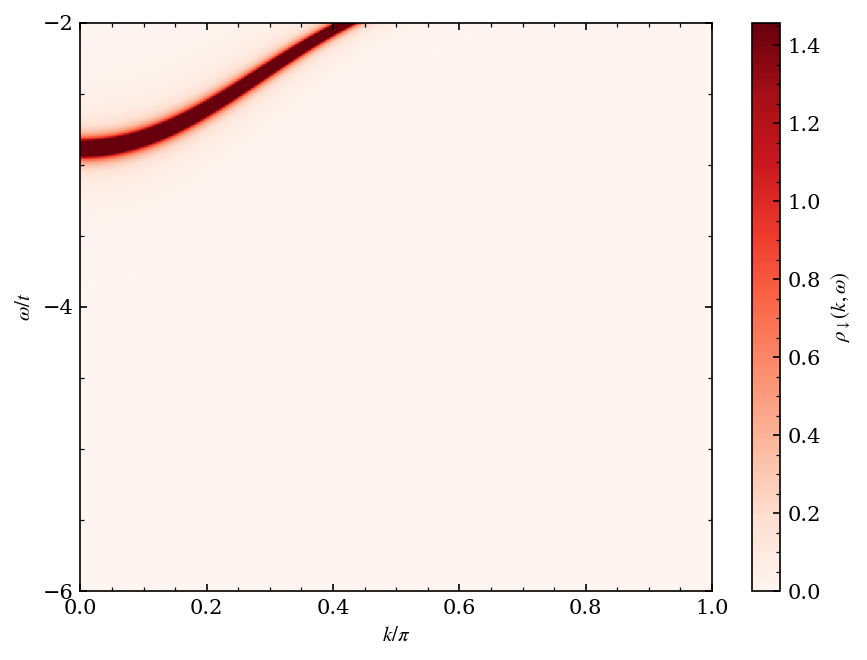

In [4]:
# ----- Parameters (consistent with SM Fig. 2) -----
s = 0.5
Je = 1.8#0.4# <-- works for any Je now
t = 1.0
J0 = 0.2
gamma = 1.0
t_v = 1.0
U = -1.0

pol = RealSpaceMagneticPolaron(t, J0, Je, s, gamma)

# Create k and omega grids
k_values = np.linspace(0, np.pi, 200)
omega_values = np.linspace(-6*t, -2*t, 200)
eta = 0.02

# Compute spectral weight on 2D grid
print("Computing spectral weight on 2D grid...")
spectral_2d = np.zeros((len(omega_values), len(k_values)))

for i, k in enumerate(k_values):
    if i % 20 == 0:
        print(f"Progress: {i}/{len(k_values)}")
    for j, omega in enumerate(omega_values):
        spectral_2d[j, i] = pol.spectral_weight(k, omega, eta=eta)

# Create the plot
fig, ax = plt.subplots(figsize=(6, 4.5))

# Plot as 2D image
im = ax.imshow(spectral_2d, 
               extent=[0, 1, omega_values[0]/t, omega_values[-1]/t],
               aspect='auto',
               origin='lower',
               cmap='Reds',  # inverted grayscale like the figure
               vmin=0,
               vmax=np.percentile(spectral_2d, 99))  # clip at 99th percentile for better contrast

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\rho_\downarrow(k,\omega)$')

# Add dashed line at omega=0 (or wherever appropriate)
#ax.axhline(-0.75, ls='--', c='grey', lw=2, alpha=0.5)
#plt.plot(k_values/np.pi, q_min_array + E_min_array)
# Labels
ax.set_xlabel(r'$k/\pi$')
ax.set_ylabel(r'$\omega/t$')
#ax.text(0.95, 0.05, '(b)', transform=ax.transAxes, 
#        fontsize=12, verticalalignment='bottom', horizontalalignment='right')
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig('spectral_function_2d.png', dpi=200, bbox_inches='tight')
print("Plot saved to outputs/spectral_function_2d.png")
#ax.axhline(11,color='r', linestyle='--')
#ax.axhline(3,color='r', linestyle='--')

#ax.axhline(-15.5,color='g', linestyle='--')
#ax.axhline(-12.5,color='g', linestyle='--')
plt.show()

In [5]:
import os
import numpy as np
from concurrent.futures import ProcessPoolExecutor




params = dict(
    t_c=t, t_v=t_v, Delta=0, J0=J0, Je=Je, Jh = 0, s=s, gamma=gamma, U=U,
    Rmax=20, M=20
)


def compute_column(args):
    k, omega_values, eta, params = args
    solver = ExcitonMagnonSolver(**params)  # build inside worker
    col = np.empty(len(omega_values), dtype=float)
    for j, w in enumerate(omega_values):
        col[j] = solver.spectral(k, w, eta=eta, R=0, m=None, source='no', Rsrc=0, msrc=None)
    return col

tasks = [(k, omega_values, eta, params) for k in k_values]

cols = []
with ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
    for i, col in enumerate(ex.map(compute_column, tasks), 1):
        cols.append(col)
        if i % 10 == 0 or i == len(tasks):
            print(f"Finished {i}/{len(tasks)} k-columns")

spectral_2d = np.stack(cols, axis=1)  # (Nw, Nk)


Finished 10/200 k-columns
Finished 20/200 k-columns
Finished 30/200 k-columns
Finished 40/200 k-columns
Finished 50/200 k-columns
Finished 60/200 k-columns
Finished 70/200 k-columns
Finished 80/200 k-columns
Finished 90/200 k-columns
Finished 100/200 k-columns
Finished 110/200 k-columns
Finished 120/200 k-columns
Finished 130/200 k-columns
Finished 140/200 k-columns
Finished 150/200 k-columns
Finished 160/200 k-columns
Finished 170/200 k-columns
Finished 180/200 k-columns
Finished 190/200 k-columns
Finished 200/200 k-columns


Plot saved to outputs/spectral_function_2d.png


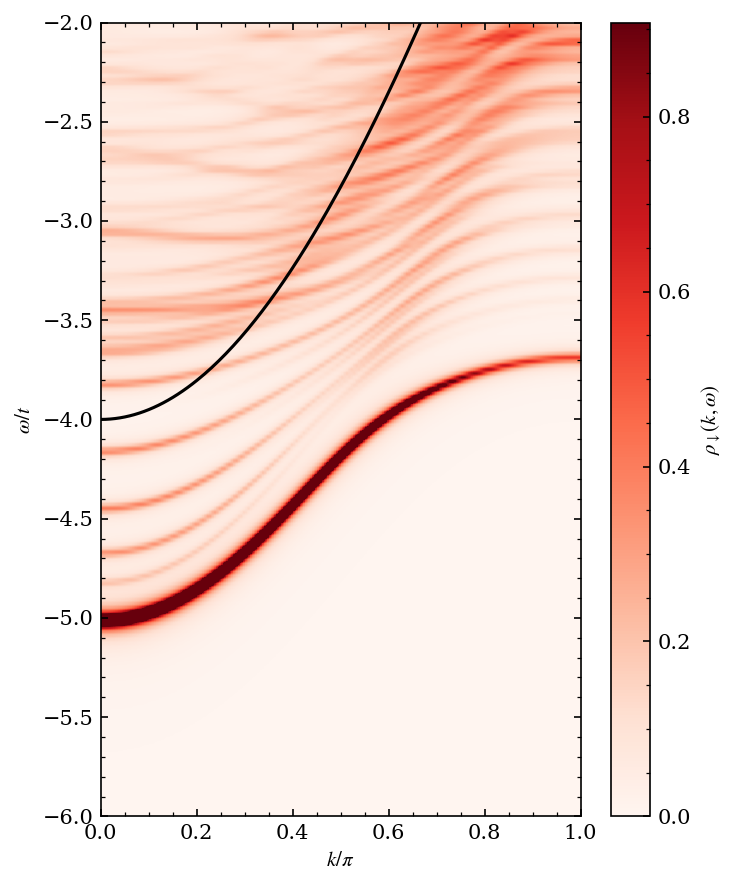

In [6]:
# Create the plot
fig, ax = plt.subplots(figsize=(5, 6))

# Plot as 2D image
im = ax.imshow(spectral_2d, 
               extent=[0, 1, omega_values[0]/t, omega_values[-1]/t],
               aspect='auto',
               origin='lower',
               cmap='Reds',  # inverted grayscale like the figure
               vmin=0,
               vmax=np.percentile(spectral_2d, 99))  # clip at 99th percentile for better contrast

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\rho_\downarrow(k,\omega)$')

#plt.plot(k_values/np.pi,-5.2-0.7*np.cos(2*k_values) )
t_c=t_v =1
#ax.plot(k_values/np.pi, E_cont, label="spin-polaron+hole")
#ax.plot(K_grid/np.pi, E_low, color='cyan', lw=2)
#plt.plot(k_values/np.pi, min_values_abs)
# Add dashed line at omega=0 (or wherever appropriate)
#ax.axhline(-0.75, ls='--', c='grey', lw=2, alpha=0.5)
#plt.plot(k_values/np.pi, q_min_array + E_min_array)
#plt.plot(k_values/np.pi, -4*np.abs(t_c*np.cos(k_values)))
#plt.plot(k_values/np.pi, -4*t_c*np.abs(np.sin(k_values/2)))
#plt.ylim(-4.4,-4.2)
# Labels
ax.set_xlabel(r'$k/\pi$')
ax.set_ylabel(r'$\omega/t$')
#ax.text(0.95, 0.05, '(b)', transform=ax.transAxes, 
#        fontsize=12, verticalalignment='bottom', horizontalalignment='right')
#ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.plot(k_values/np.pi, -4*t_c*np.abs(np.cos(k_values/2)), color = "k", lw = 1.5)
plt.savefig('spectral_function_2d.png', dpi=200, bbox_inches='tight')
print("Plot saved to outputs/spectral_function_2d.png")
#ax.axhline(11,color='r', linestyle='--')
#ax.axhline(3,color='r', linestyle='--')
ax.set_ylim(-6, -2)
#ax.axhline(-15.5,color='g', linestyle='--')
#ax.axhline(-12.5,color='g', linestyle='--')
plt.show()

Extracting spin polaron band for J1=0.4...


/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:53: RuntimeWarning: divide by zero encountered in cdouble_scalars
/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:53: RuntimeWarning: invalid value encountered in cdouble_scalars


  Found poles at 500/500 k-points
  Min binding energy: 0.012173
  Max binding energy: 0.246024
Saved plot.
Saved data.


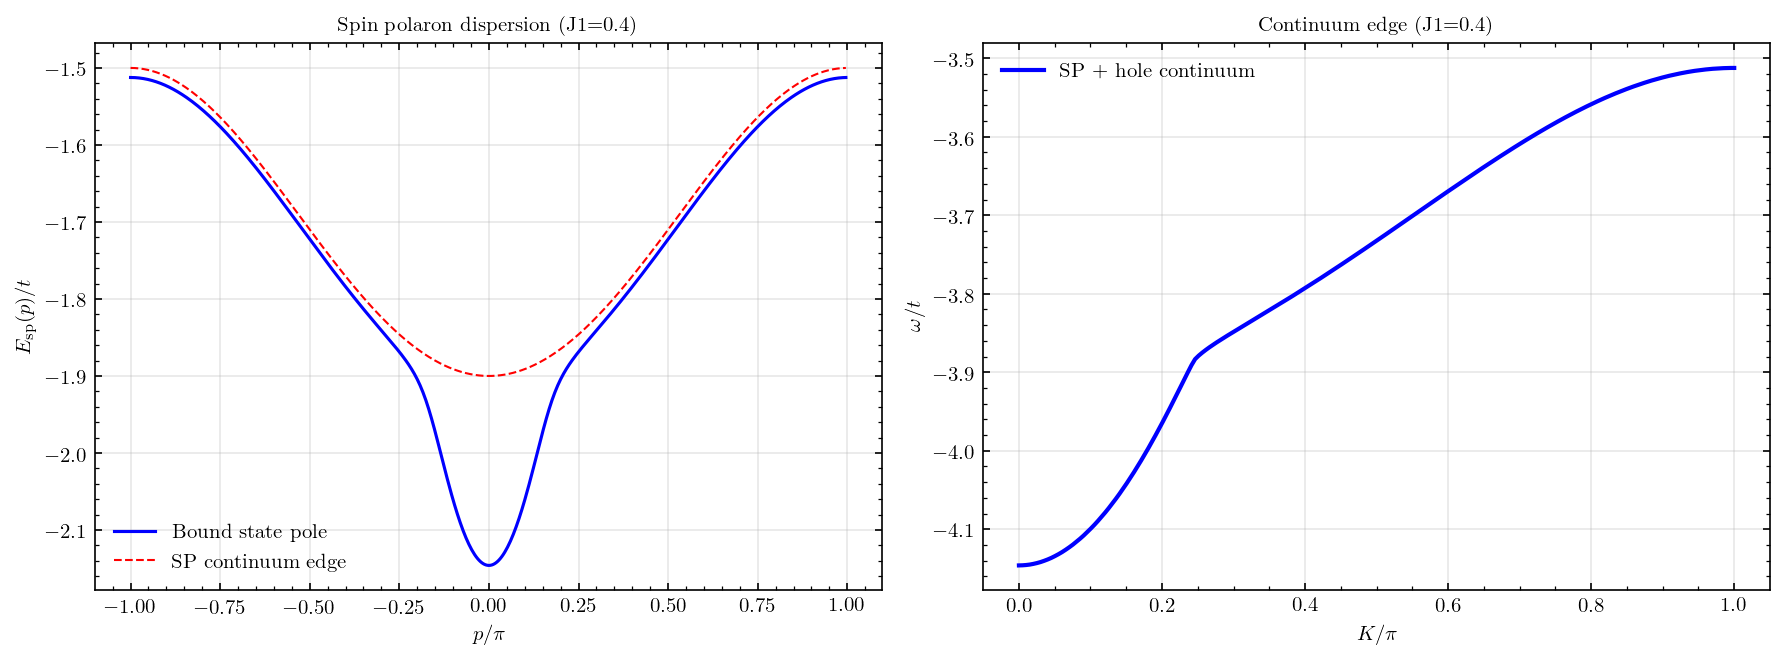

In [25]:
def extract_lowest_spin_polaron_band(pol, p_grid, wmin=-8.0, padding=1e-8):
    """
    Exact pole extraction.
    1. For each p, compute the spin-polaron continuum edge E_cont(p).
    2. Search for the pole of D(omega, p) = 0 in [wmin, E_cont(p) - padding].
    3. Use a coarse scan + brentq refinement.
    """
    n_p = len(p_grid)
    E_sp = np.full(n_p, np.nan, dtype=float)

    # Step 1: continuum edges (vectorized over q, looped over p)
    E_cont = np.array([pol.sp_continuum_edge(p) for p in p_grid])

    # Step 2: for each p, find the pole below E_cont
    for j, p in enumerate(p_grid):
        w_lo = wmin
        w_hi = E_cont[j] - padding

        if w_hi <= w_lo:
            continue

        # Coarse scan
        n_scan = 2000
        w_scan = np.linspace(w_lo, w_hi, n_scan)
        D_scan = np.array([pol.denominator_real_below_continuum(w, p) for w in w_scan])

        # Find sign changes
        sign_changes = np.where(np.diff(np.signbit(D_scan)))[0]

        if len(sign_changes) == 0:
            # Adaptive refinement near the continuum edge
            # Use geometrically spaced points to resolve arbitrarily small binding
            found_fine = False
            for depth in range(8):  # each level 10x finer
                width = 0.5 * (0.1 ** depth)
                w_lo_fine = max(w_lo, w_hi - width)
                if w_hi - w_lo_fine < 1e-15:
                    break
                w_scan_fine = np.linspace(w_lo_fine, w_hi, 2000)
                D_scan_fine = np.array([pol.denominator_real_below_continuum(w, p)
                                        for w in w_scan_fine])
                sign_changes_fine = np.where(np.diff(np.signbit(D_scan_fine)))[0]
                if len(sign_changes_fine) > 0:
                    roots = []
                    for i in sign_changes_fine:
                        try:
                            root = brentq(
                                lambda w: pol.denominator_real_below_continuum(w, p),
                                w_scan_fine[i], w_scan_fine[i+1], xtol=1e-14)
                            roots.append(root)
                        except:
                            pass
                    if roots:
                        E_sp[j] = min(roots)
                        found_fine = True
                    break
            if not found_fine:
                continue

        # Refine all brackets, take the lowest
        roots = []
        for i in sign_changes:
            try:
                root = brentq(lambda w: pol.denominator_real_below_continuum(w, p),
                              w_scan[i], w_scan[i+1], xtol=1e-14)
                roots.append(root)
            except:
                pass
        if roots:
            E_sp[j] = min(roots)

    return E_sp, E_cont


def wrap_to_bz(x):
    return (x + np.pi) % (2.0 * np.pi) - np.pi


def spin_polaron_hole_continuum(K_ex_grid, p_grid, E_sp, t_v):
    """
    Exciton-solver convention:
        p_sp + k_h = 2 K_ex
    Hole dispersion:
        E_h(k_h) = -2 t_v cos(k_h)
    So:
        E_cont(K_ex) = min_p [ E_sp(p) - 2 t_v cos(K_ex - p) ]
    """
    K_ex_grid = np.asarray(K_ex_grid, dtype=float)
    p_grid = np.asarray(p_grid, dtype=float)
    E_sp = np.asarray(E_sp, dtype=float)

    # Mask out NaN values
    valid = ~np.isnan(E_sp)
    p_valid = p_grid[valid]
    E_valid = E_sp[valid]

    E_mat = E_valid[None, :] - 2.0 * t_v * np.cos(K_ex_grid[:, None] - p_valid[None, :])
    idx = np.argmin(E_mat, axis=1)
    E_cont = E_mat[np.arange(K_ex_grid.size), idx]
    p_star = p_valid[idx]
    k_h_star = wrap_to_bz(K_ex_grid - p_star)
    return E_cont, p_star, k_h_star


# =====================================================
# Parameters — change Je here
# =====================================================

pol = RealSpaceMagneticPolaron(t=t, J_0=J0, J_e=Je, s=s, gamma=gamma)

# 1) Exact spin-polaron dispersion
p_grid = np.linspace(-np.pi, np.pi, 500, endpoint=False)
print(f"Extracting spin polaron band for Je={Je}...")
E_sp, E_sp_cont = extract_lowest_spin_polaron_band(pol, p_grid, wmin=omega_values[0])

n_valid = np.sum(~np.isnan(E_sp))
n_total = len(E_sp)
print(f"  Found poles at {n_valid}/{n_total} k-points")
if n_valid < n_total:
    n_missing = n_total - n_valid
    missing_k = p_grid[np.isnan(E_sp)]
    print(f"  Missing poles near k/pi = {missing_k[:5]/np.pi} ...")

# Check binding energy
binding = E_sp_cont - E_sp
print(f"  Min binding energy: {np.nanmin(binding):.6f}")
print(f"  Max binding energy: {np.nanmax(binding):.6f}")

# 2) Build the sp + hole continuum
K_ex = k_values
E_cont, p_star, k_h_star = spin_polaron_hole_continuum(
    K_ex_grid=K_ex, p_grid=p_grid, E_sp=E_sp, t_v=t_v
)

# 3) Plot spin-polaron band + continuum
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(p_grid/np.pi, E_sp, 'b-', lw=1.5, label='Bound state pole')
ax1.plot(p_grid/np.pi, E_sp_cont, 'r--', lw=1, label='SP continuum edge')
ax1.set_xlabel(r'$p/\pi$')
ax1.set_ylabel(r'$E_{\rm sp}(p)/t$')
ax1.set_title(f'Spin polaron dispersion (Je={Je})')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(K_ex/np.pi, E_cont, 'b-', lw=2, label='SP + hole continuum')
ax2.set_xlabel(r'$K/\pi$')
ax2.set_ylabel(r'$\omega/t$')
ax2.set_title(f'Continuum edge (Je={Je})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sp_continuum_Je_{:.1f}.png'.format(Je), dpi=200, bbox_inches='tight')
print(f"Saved plot.")

# Save data
np.savez('sp_continuum_data_Je_{:.1f}.npz'.format(Je),
         p_grid=p_grid, E_sp=E_sp, E_sp_cont=E_sp_cont,
         K_ex=K_ex, E_cont=E_cont, p_star=p_star, k_h_star=k_h_star)
print("Saved data.")
plt.show()

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def wrap_to_pi(x):
    return (x + np.pi) % (2*np.pi) - np.pi

def exciton_bound_energy(k, t_c, t_v, U, Je=0.0, s=0.5):
    """
    Exact exciton bound-state dispersion in the reduced momentum variable k,
    where the formula depends on cos(k).

    k can be scalar or array.
    """
    A = t_c**2 + t_v**2 + 2.0*t_c*t_v*np.cos(k)
    E = -np.sqrt(U**2 + 4.0*A)   # lower / bound branch
    return E



def magnon_dispersion(q, J0, s, Je):
    """
    Exact 1D FM magnon dispersion in the same energy convention as your solver.
    """
    return 2.0*J0*s*(1.0 - np.cos(q)) + Je*s/2

def exciton_magnon_continuum(K_grid, t_c, t_v, U, J0, s, Je=0.0,
                             nq=2002):
    """
    Exciton + magnon continuum in the exciton-magnon solver convention.

    K_grid: solver momentum variable K in [0, pi]
    q: physical magnon momentum in [-pi, pi)
    Exciton reduced momentum is k_X = K - q, so cos( k_X) = cos(K - q).

    Returns:
      E_low(K), E_high(K), q_star_low(K), q_star_high(K), E_all(K,q)
    """
    K_grid = np.asarray(K_grid, dtype=float)
    q_grid = np.linspace(-np.pi, np.pi, nq, endpoint=False)

    # Broadcast over K and q
    K2 = K_grid[:, None]
    Q  = q_grid[None, :]

    # Exciton reduced momentum in your exact formula
    kX = K2 - Q

    EX = exciton_bound_energy(
        kX, t_c=t_c, t_v=t_v, U=U, Je=Je, s=s
    )
    WM = magnon_dispersion(Q, J0=J0, s=s, Je=Je)

    E_all = EX + WM

    idx_low  = np.argmin(E_all, axis=1)
    idx_high = np.argmax(E_all, axis=1)

    E_low  = E_all[np.arange(len(K_grid)), idx_low]
    E_high = E_all[np.arange(len(K_grid)), idx_high]

    q_star_low  = q_grid[idx_low]
    q_star_high = q_grid[idx_high]

    return E_low, E_high, q_star_low, q_star_high, q_grid, E_all

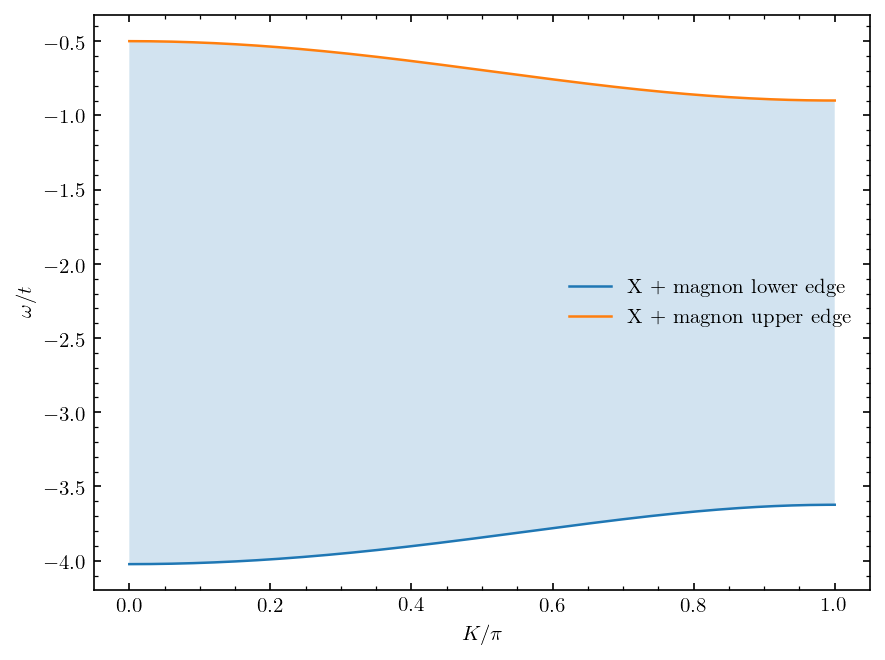

In [27]:
# Parameters


K_grid = k_values

E_low, E_high, q_low, q_high, q_grid, E_all = exciton_magnon_continuum(
    K_grid,
    t_c=t_c,
    t_v=t_v,
    U=U,
    J0=J0,
    s=s,
    Je=Je,
    nq=2002,
)

# Plot edges
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(K_grid/np.pi, E_low,  label='X + magnon lower edge')
ax.plot(K_grid/np.pi, E_high, label='X + magnon upper edge')
ax.fill_between(K_grid/np.pi, E_low, E_high, alpha=0.2)
ax.set_xlabel(r'$K/\pi$')
ax.set_ylabel(r'$\omega/t$')
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
pol = RealSpaceMagneticPolaron(t=t, J_0=J0, J_e=Je, s=s, gamma=gamma)

# 1) Exact spin-polaron dispersion
p_grid = np.linspace(-np.pi, np.pi, 400, endpoint=False)
print(f"Extracting spin polaron band for Je={Je}...")
E_sp, E_sp_cont = extract_lowest_spin_polaron_band(pol, p_grid, wmin=-8.0*t)

n_valid = np.sum(~np.isnan(E_sp))
n_total = len(E_sp)
print(f"  Found poles at {n_valid}/{n_total} k-points")
if n_valid < n_total:
    n_missing = n_total - n_valid
    missing_k = p_grid[np.isnan(E_sp)]
    print(f"  Missing poles near k/pi = {missing_k[:5]/np.pi} ...")

# Check binding energy
binding = E_sp_cont - E_sp
print(f"  Min binding energy: {np.nanmin(binding):.6f}")
print(f"  Max binding energy: {np.nanmax(binding):.6f}")

# 2) Build the sp + hole continuum
K_ex = k_values
E_cont, p_star, k_h_star = spin_polaron_hole_continuum(
    K_ex_grid=K_ex, p_grid=p_grid, E_sp=E_sp, t_v=t_v
)

Extracting spin polaron band for J1=0.4...


/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:53: RuntimeWarning: divide by zero encountered in cdouble_scalars
/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:53: RuntimeWarning: invalid value encountered in cdouble_scalars


  Found poles at 400/400 k-points
  Min binding energy: 0.012173
  Max binding energy: 0.246024


Plot saved to outputs/spectral_function_2d.png


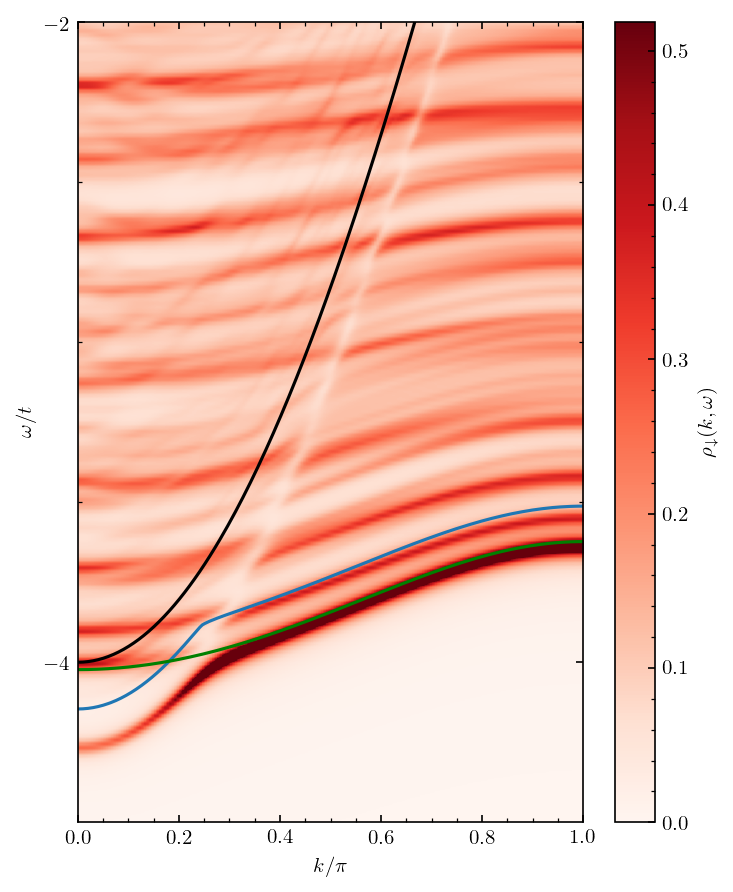

In [29]:
# Create the plot
fig, ax = plt.subplots(figsize=(5, 6))

# Plot as 2D image
im = ax.imshow(spectral_2d, 
               extent=[0, 1, omega_values[0]/t, omega_values[-1]/t],
               aspect='auto',
               origin='lower',
               cmap='Reds',  # inverted grayscale like the figure
               vmin=0,
               vmax=np.percentile(spectral_2d, 99))  # clip at 99th percentile for better contrast

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\rho_\downarrow(k,\omega)$')

#plt.plot(k_values/np.pi,-5.2-0.7*np.cos(2*k_values) )
t_c=t_v =1
ax.plot(k_values/np.pi, E_cont, label="spin-polaron+hole", lw=1.5)
ax.plot(K_grid/np.pi, E_low , color='g', lw=1.5)
#plt.plot(k_values/np.pi, min_values_abs)
# Add dashed line at omega=0 (or wherever appropriate)
#ax.axhline(-0.75, ls='--', c='grey', lw=2, alpha=0.5)
#plt.plot(k_values/np.pi, q_min_array + E_min_array)
#plt.plot(k_values/np.pi, -4*np.abs(t_c*np.cos(k_values)))
plt.plot(k_values/np.pi, -4*t_c*np.abs(np.cos(k_values/2)), color = "k", lw=1.5)
#plt.ylim(-4.4,-4.2)
# Labels
ax.set_xlabel(r'$k/\pi$')
ax.set_ylabel(r'$\omega/t$')
#ax.text(0.95, 0.05, '(b)', transform=ax.transAxes, 
#        fontsize=12, verticalalignment='bottom', horizontalalignment='right')
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig('spectral_function_2d.png', dpi=200, bbox_inches='tight')
print("Plot saved to outputs/spectral_function_2d.png")
#ax.axhline(11,color='r', linestyle='--')
#ax.axhline(3,color='r', linestyle='--')
ax.set_ylim(-4.5, -2)
#ax.axhline(-15.5,color='g', linestyle='--')
#ax.axhline(-12.5,color='g', linestyle='--')
plt.show()

/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:53: RuntimeWarning: divide by zero encountered in cdouble_scalars
/home/mchu03/venvs/specmap/lib64/python3.6/site-packages/ipykernel_launcher.py:53: RuntimeWarning: invalid value encountered in cdouble_scalars


J1 =  0.40 | X+magnon: low = -4.123106, high = -0.600000, q* =  0.000 pi | SP+hole: low = -4.146023, p* =  0.000 pi, kh* =  0.000 pi


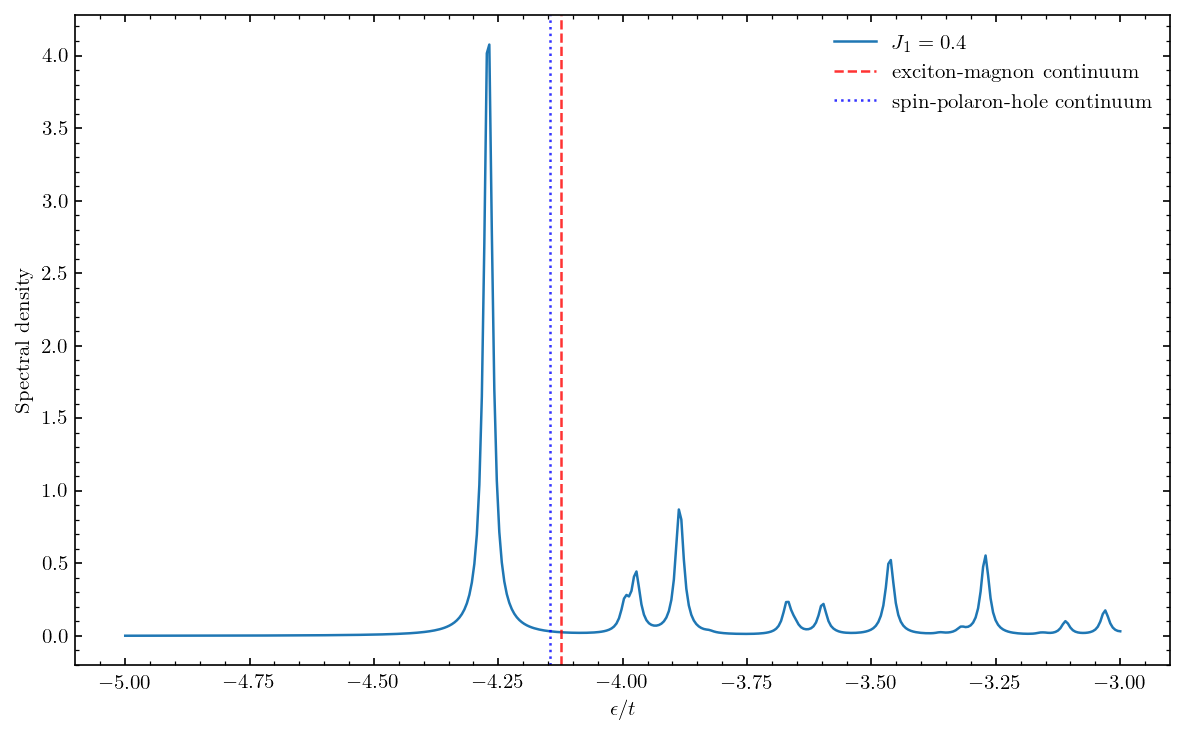

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# =====================================================
# ORIGINAL EXACT SPIN-POLARON EXTRACTION
# Keep this one only. Delete any later redefinition.
# =====================================================

def extract_lowest_spin_polaron_band(pol, p_grid, wmin=-8.0, padding=1e-8):
    """
    Exact pole extraction.
    1. For each p, compute the spin-polaron continuum edge E_cont(p).
    2. Search for the pole of D(omega, p) = 0 in [wmin, E_cont(p) - padding].
    3. Use a coarse scan + brentq refinement.
    """
    n_p = len(p_grid)
    E_sp = np.full(n_p, np.nan, dtype=float)

    # Step 1: continuum edges
    E_cont = np.array([pol.sp_continuum_edge(p) for p in p_grid])

    # Step 2: pole below continuum
    for j, p in enumerate(p_grid):
        w_lo = wmin
        w_hi = E_cont[j] - padding

        if w_hi <= w_lo:
            continue

        # coarse scan
        n_scan = 200
        w_scan = np.linspace(w_lo, w_hi, n_scan)
        D_scan = np.array([pol.denominator_real_below_continuum(w, p) for w in w_scan])

        sign_changes = np.where(np.diff(np.signbit(D_scan)))[0]

        if len(sign_changes) == 0:
            # refine near continuum edge
            found_fine = False
            for depth in range(8):
                width = 0.5 * (0.1 ** depth)
                w_lo_fine = max(w_lo, w_hi - width)
                if w_hi - w_lo_fine < 1e-15:
                    break

                w_scan_fine = np.linspace(w_lo_fine, w_hi, 2000)
                D_scan_fine = np.array([
                    pol.denominator_real_below_continuum(w, p)
                    for w in w_scan_fine
                ])
                sign_changes_fine = np.where(np.diff(np.signbit(D_scan_fine)))[0]

                if len(sign_changes_fine) > 0:
                    roots = []
                    for i in sign_changes_fine:
                        try:
                            root = brentq(
                                lambda w: pol.denominator_real_below_continuum(w, p),
                                w_scan_fine[i], w_scan_fine[i+1], xtol=1e-14
                            )
                            roots.append(root)
                        except Exception:
                            pass
                    if roots:
                        E_sp[j] = min(roots)
                        found_fine = True
                    break

            if not found_fine:
                continue

        roots = []
        for i in sign_changes:
            try:
                root = brentq(
                    lambda w: pol.denominator_real_below_continuum(w, p),
                    w_scan[i], w_scan[i+1], xtol=1e-14
                )
                roots.append(root)
            except Exception:
                pass

        if roots:
            E_sp[j] = min(roots)

    return E_sp, E_cont


def wrap_to_bz(x):
    return (x + np.pi) % (2.0 * np.pi) - np.pi


# =====================================================
# ORIGINAL SP + HOLE CONTINUUM
# rewritten only so scalar K0 works naturally
# =====================================================

def spin_polaron_hole_continuum(K_ex_grid, p_grid, E_sp, t_v):
    """
    Exciton-solver convention:
        p_sp + k_h = K_ex
    Hole dispersion:
        E_h(k_h) = -2 t_v cos(k_h)
    So:
        E_cont(K_ex) = min_p [ E_sp(p) - 2 t_v cos(K_ex - p) ]
    """
    scalar_input = np.ndim(K_ex_grid) == 0
    K_ex_grid = np.atleast_1d(np.asarray(K_ex_grid, dtype=float))
    p_grid = np.asarray(p_grid, dtype=float)
    E_sp = np.asarray(E_sp, dtype=float)

    valid = ~np.isnan(E_sp)
    p_valid = p_grid[valid]
    E_valid = E_sp[valid]

    E_mat = E_valid[None, :] - 2.0 * t_v * np.cos(K_ex_grid[:, None] - p_valid[None, :])
    idx = np.argmin(E_mat, axis=1)

    E_cont = E_mat[np.arange(K_ex_grid.size), idx]
    p_star = p_valid[idx]
    k_h_star = wrap_to_bz(K_ex_grid - p_star)

    if scalar_input:
        return E_cont[0], p_star[0], k_h_star[0]
    return E_cont, p_star, k_h_star


# =====================================================
# ORIGINAL X + MAGNON CONTINUUM
# also rewritten to allow scalar K0 directly
# =====================================================

def exciton_bound_energy(k_red, t_c, t_v, U, Je=0.0, s=0.5):
    A = t_c**2 + t_v**2 + 2.0 * t_c * t_v * np.cos(k_red)
    E = -np.sqrt(U**2 + 4.0 * A)
    return E

def magnon_dispersion(q, J0, s, Je):
    return 2.0 * J0 * s * (1.0 - np.cos(q))

def exciton_magnon_continuum(K_grid, t_c, t_v, U, J0, s, Je=0.0,
                             nq=2002):
    """
    Same structure as your original full-K code, but accepts scalar K too.
    """
    scalar_input = np.ndim(K_grid) == 0
    K_grid = np.atleast_1d(np.asarray(K_grid, dtype=float))
    q_grid = np.linspace(-np.pi, np.pi, nq, endpoint=False)

    K2 = K_grid[:, None]
    Q = q_grid[None, :]

    # same convention you were using before
    kX = K2 - Q

    EX = exciton_bound_energy(
        kX, t_c=t_c, t_v=t_v, U=U, Je=Je, s=s,
    )
    WM = magnon_dispersion(Q, J0=J0, s=s, Je=Je)

    E_all = EX + WM

    idx_low = np.argmin(E_all, axis=1)
    idx_high = np.argmax(E_all, axis=1)

    E_low = E_all[np.arange(len(K_grid)), idx_low]
    E_high = E_all[np.arange(len(K_grid)), idx_high]

    q_star_low = q_grid[idx_low]
    q_star_high = q_grid[idx_high]

    if scalar_input:
        return E_low[0], E_high[0], q_star_low[0], q_star_high[0]
    return E_low, E_high, q_star_low, q_star_high, q_grid, E_all


# =====================================================
# PARAMETERS
# =====================================================

t_c = 1.0
t_v = 1.0
Delta = 0.0
J0 = 0.2
s = 0.5
gamma = 1.0
U = -1.0
Rmax = 10
M = 5
eta = 0.01
K0 = 0.0

omegas = np.linspace(-5, -3, 400)
Je_list = [0.4]


# =====================================================
# FIXED-K SPECTRUM
# =====================================================

def spectrum_at_K0(Je):
    solver = ExcitonMagnonSolver(
        t_c=t_c, t_v=t_v, Delta=Delta,
        J0=J0, Je=Je, s=s, gamma=gamma, U=U,
        Rmax=Rmax, M=M
    )
    return np.array([
        solver.spectral(K0, w, eta=eta, R=1, m=None, source='no', Rsrc=1)
        for w in omegas
    ])


# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(8, 5))

for Je in Je_list:
    # spectral function
    A = spectrum_at_K0(Je)
    plt.plot(omegas, A, label=fr"$J_e={Je}$")

    # X + magnon continuum at K0
    exm_low, exm_high, q_low, q_high = exciton_magnon_continuum(
        K0, t_c=t_c, t_v=t_v, U=U, J0=J0, s=s, Je=Je, nq=2002
    )

    # exact spin-polaron band
    pol = RealSpaceMagneticPolaron(t=t_c, J_0=J0, J_e=Je, s=s, gamma=gamma)
    p_grid = np.linspace(-np.pi, np.pi, 500, endpoint=False)
    E_sp, E_sp_cont = extract_lowest_spin_polaron_band(pol, p_grid, wmin=omegas[0])

    # SP + hole continuum at K0
    sph_low, p_star, k_h_star = spin_polaron_hole_continuum(K0, p_grid, E_sp, t_v)

    # plot lower edges only
    plt.axvline(exm_low, color="red", linestyle="--", alpha=0.8, label="exciton-magnon continuum")
    plt.axvline(sph_low, color="blue", linestyle=":", alpha=0.8, label="spin-polaron-hole continuum")

    print(
        f"Je = {Je:5.2f} | "
        f"X+magnon: low = {exm_low: .6f}, high = {exm_high: .6f}, q* = {q_low/np.pi: .3f} pi | "
        f"SP+hole: low = {sph_low: .6f}, p* = {p_star/np.pi: .3f} pi, kh* = {k_h_star/np.pi: .3f} pi"
    )

plt.legend()
plt.xlabel(r'$\epsilon/t$')
plt.ylabel("Spectral density")
plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from concurrent.futures import ProcessPoolExecutor
from multiprocessing import get_context


# ---------------------------------------------------------
# Your existing classes / functions
# ---------------------------------------------------------
class RealSpaceMagneticPolaron:
    def __init__(self, t, J_0, J_e, s, gamma=1.0):
        self.t = float(t)
        self.J_0 = float(J_0)
        self.J_e = float(J_e)
        self.s = float(s)
        self.gamma = float(gamma)

    def denominator(self, z, K):
        z = np.asarray(z, dtype=np.complex128)
        K = np.asarray(K, dtype=float)
        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0
        alpha = z - 2.0 * self.J_0 * self.s + 0.5 * self.J_e * self.s
        disc = alpha**2 - 4.0 * A_plus * A_minus
        sqrt_disc = np.sqrt(disc + 0j)
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = np.where(np.abs(rho1) < np.abs(rho2), rho1, rho2)
        beta = z - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * (self.s - 1.0)
        g2 = (self.gamma * self.J_e)**2 * self.s / 2.0
        Sigma = g2 / (beta + 2.0 * A_minus * rho)
        return z + 2.0 * self.t * np.cos(K) - 0.5 * self.J_e * self.s - Sigma

    def denominator_real_below_continuum(self, omega, K, tol=1e-14, blowup=1e300):
        """
        Real-axis denominator below the continuum, with explicit handling of
        self-energy poles to avoid warnings / NaNs during scans.
        """
        omega = float(omega)
        K = float(K)

        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0

        alpha = omega - 2.0 * self.J_0 * self.s + 0.5 * self.J_e * self.s
        disc = alpha**2 - 4.0 * (A_plus * A_minus)

        # below continuum this should be real and >= 0 up to roundoff
        disc_real = disc.real
        if disc_real < 0 and disc_real > -1e-12:
            disc_real = 0.0
        elif disc_real < 0:
            # outside intended domain
            return np.nan

        sqrt_disc = np.sqrt(disc_real)

        # choose decaying branch
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = rho1 if abs(rho1) < abs(rho2) else rho2

        beta = omega - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * (self.s - 1.0)
        g2 = (self.gamma * self.J_e)**2 * self.s / 2.0

        denom_sigma = beta + 2.0 * A_minus * rho

        # below continuum this should be real up to roundoff
        denom_sigma_real = denom_sigma.real

        bare = omega + 2.0 * self.t * np.cos(K) + 0.5 * self.J_e * self.s

        # handle self-energy pole explicitly
        if abs(denom_sigma_real) < tol:
            return -np.copysign(blowup, denom_sigma_real if denom_sigma_real != 0.0 else 1.0)

        return bare - g2 / denom_sigma_real

    def sp_continuum_edge(self, K):
        K = float(K)
        q_grid = np.linspace(-np.pi, np.pi, 5000)
        E_vals = (-2.0 * self.t * np.cos(K - q_grid)
                  + 2.0 * self.J_0 * self.s * (1.0 - np.cos(q_grid))
                  + 0.5 * self.J_e * self.s)
        return np.min(E_vals)


def extract_lowest_spin_polaron_band(pol, p_grid, wmin=-8.0, padding=1e-8):
    n_p = len(p_grid)
    E_sp = np.full(n_p, np.nan, dtype=float)
    E_cont = np.array([pol.sp_continuum_edge(p) for p in p_grid])

    for j, p in enumerate(p_grid):
        w_lo = wmin
        w_hi = E_cont[j] - padding
        if w_hi <= w_lo:
            continue

        n_scan = 2000
        w_scan = np.linspace(w_lo, w_hi, n_scan)
        D_scan = np.array([pol.denominator_real_below_continuum(w, p) for w in w_scan])

        sign_changes = np.where(np.diff(np.signbit(D_scan)))[0]

        if len(sign_changes) == 0:
            found_fine = False
            for depth in range(8):
                width = 0.5 * (0.1 ** depth)
                w_lo_fine = max(w_lo, w_hi - width)
                if w_hi - w_lo_fine < 1e-15:
                    break
                w_scan_fine = np.linspace(w_lo_fine, w_hi, 2000)
                D_scan_fine = np.array([pol.denominator_real_below_continuum(w, p)
                                        for w in w_scan_fine])
                sign_changes_fine = np.where(np.diff(np.signbit(D_scan_fine)))[0]
                if len(sign_changes_fine) > 0:
                    roots = []
                    for i in sign_changes_fine:
                        try:
                            root = brentq(
                                lambda w: pol.denominator_real_below_continuum(w, p),
                                w_scan_fine[i], w_scan_fine[i + 1], xtol=1e-14
                            )
                            roots.append(root)
                        except Exception:
                            pass
                    if roots:
                        E_sp[j] = min(roots)
                        found_fine = True
                    break
            if not found_fine:
                continue

        roots = []
        for i in sign_changes:
            try:
                root = brentq(
                    lambda w: pol.denominator_real_below_continuum(w, p),
                    w_scan[i], w_scan[i + 1], xtol=1e-14
                )
                roots.append(root)
            except Exception:
                pass
        if roots:
            E_sp[j] = min(roots)

    return E_sp, E_cont


def exciton_magnon_edge_K0(U, Je, t_c, t_v, s):
    return +0.5 * Je * s - np.sqrt(U**2 + 4.0 * (t_c + t_v)**2)


def spin_polaron_hole_edge_K0(pol, p_grid, t_v, wmin=-8.0):
    E_sp, E_sp_cont = extract_lowest_spin_polaron_band(pol, p_grid, wmin=wmin)
    valid = np.isfinite(E_sp)
    if not np.any(valid):
        return np.nan, np.nan

    vals = E_sp[valid] - 2.0 * t_v * np.cos(p_grid[valid])
    idx = np.argmin(vals)
    return vals[idx], p_grid[valid][idx]


# ---------------------------------------------------------
# Parallel worker
# ---------------------------------------------------------
def _compute_one_Je(job):
    """
    Top-level function so it is picklable by ProcessPoolExecutor.
    """
    Je, t, J0, s, gamma, t_v, p_points, wmin = job

    p_grid = np.linspace(-np.pi, np.pi, p_points, endpoint=False)
    pol = RealSpaceMagneticPolaron(t=t, J_0=J0, J_e=Je, s=s, gamma=gamma)
    E_edge, p_star = spin_polaron_hole_edge_K0(pol, p_grid=p_grid, t_v=t_v, wmin=wmin)

    return Je, E_edge, p_star


import os
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

# ---------------------------------------------------
# Worker: one independent Je job
# ---------------------------------------------------
def compute_one_Je(args):
    Je, p_grid, t, J0, s, gamma, t_v, wmin = args

    pol = RealSpaceMagneticPolaron(t=t, J_0=J0, J_e=Je, s=s, gamma=gamma)

    # exact standalone spin-polaron band
    E_sp, E_sp_cont = extract_lowest_spin_polaron_band(pol, p_grid, wmin=wmin)

    valid = ~np.isnan(E_sp)
    if not np.any(valid):
        return np.nan, np.nan, E_sp, E_sp_cont

    # K_ex = 0  =>  p_sp + k_h = 0  =>  k_h = -p_sp
    # E_h(-p) = -2 t_v cos(p)
    vals = E_sp[valid] - 2.0 * t_v * np.cos(p_grid[valid])
    idx = np.argmin(vals)

    E_edge = vals[idx]
    p_star = p_grid[valid][idx]

    return E_edge, p_star, E_sp, E_sp_cont


# ---------------------------------------------------
# Parameters
# ---------------------------------------------------
t_c = 1.0
t_v = 1.0
t   = 1.0
J0  = 0.1
s   = 0.5
gamma = 1.0

# scan ranges
U_grid  = np.linspace(-4.0, 0.0, 301)
Je_grid = np.linspace(0.1, 3.0, 60)

# momentum grid for standalone spin polaron
p_grid = np.linspace(-np.pi, np.pi, 500, endpoint=False)

# lower search bound for pole finder
wmin = -8.0 * t

tasks = [(Je, p_grid, t, J0, s, gamma, t_v, wmin) for Je in Je_grid]

E_sph = np.full(len(Je_grid), np.nan)
p_star = np.full(len(Je_grid), np.nan)

# optional: keep these if you want diagnostics later
E_sp_all = []
E_sp_cont_all = []

with ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
    for i, result in enumerate(ex.map(compute_one_Je, tasks), 1):
        E_edge, pmin, E_sp, E_sp_cont = result
        E_sph[i-1] = E_edge
        p_star[i-1] = pmin
        E_sp_all.append(E_sp)
        E_sp_cont_all.append(E_sp_cont)

        if i % 5 == 0 or i == len(tasks):
            print(f"Finished {i}/{len(tasks)} Je runs")
            
# ---------------------------------------------------
# Exciton + magnon lower edge at K=0
# direct-gap assumption => minimum at q=0
# ---------------------------------------------------
E_xm = (
    +0.5 * s * Je_grid[:, None]
    - np.sqrt(U_grid[None, :]**2 + 4.0 * (t_c + t_v)**2)
)

# difference:
# Delta < 0  => exciton+magnon lower
# Delta > 0  => spin-polaron+hole lower
Delta = E_xm - E_sph[:, None]

# exact crossover U_c(Je) from Delta = 0
rhs = (-E_sph - 0.5 * s * Je_grid)**2 - 4.0 * (t_c + t_v)**2
U_cross = np.full_like(Je_grid, np.nan, dtype=float)
mask = np.isfinite(rhs) & (rhs >= 0.0)
U_cross[mask] = -np.sqrt(rhs[mask])
from matplotlib.colors import TwoSlopeNorm

v = np.nanmax(np.abs(Delta))   # symmetric range around 0
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(
    Delta,
    origin='lower',
    aspect='auto',
    extent=[U_grid[0], U_grid[-1], Je_grid[0], Je_grid[-1]],
    cmap='bwr',   # blue-white-red
    norm=norm
)

ax.contour(
    U_grid,
    Je_grid,
    Delta,
    levels=[0.0],
    colors='k',
    linewidths=2
)

cbar = plt.colorbar(im, ax=ax)
#cbar.set_label(r'$\Delta = E_{X+m}(0) - E_{sp+h}(0)$')

ax.set_xlabel(r'$U$')
ax.set_ylabel(r'$J_e$')
#ax.set_title(r'Crossover at $K=0$')
plt.tight_layout()
plt.show()

ax.contour(
    U_grid,
    Je_grid,
    Delta,
    levels=[0.0],
    colors='k',
    linewidths=2
)

cbar = plt.colorbar(im, ax=ax)
#cbar.set_label(r'$\Delta = E_{X+m}(0) - E_{sp+h}(0)$')



fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(Je_grid, U_cross, lw=2)
ax.set_xlabel(r'$J_e$')
ax.set_ylabel(r'$U_c$')
#ax.set_title(r'Crossover line at $K=0$')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

All done — building figure.


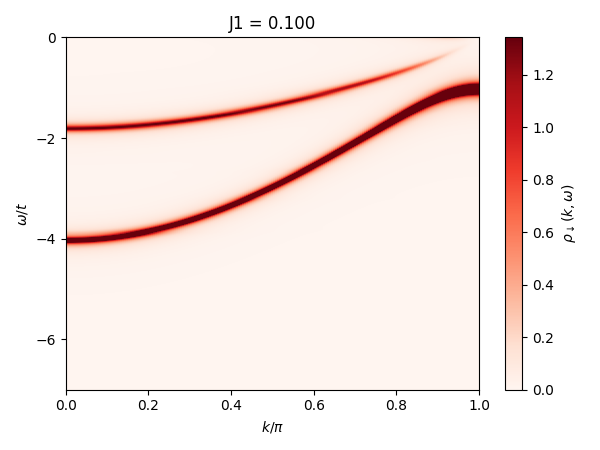

SelectionSlider(description='J1', layout=Layout(width='500px'), options=(('J1 = 0.100', 0.1), ('J1 = 0.200', 0…

In [14]:
%matplotlib ipympl
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import ipywidgets as widgets
from concurrent.futures import ProcessPoolExecutor

# ── 1. Parameter sweep over Je ───────────────────────────────────────────────
PARAM_NAME   = 'Je'
param_values = np.linspace(0.1, 1, 10)   # Je = 0.0, 0.22, 0.44, ..., 2.0

base_params = dict(
    t_c=1.0, t_v=1.0, Delta=0, J0=0.05, Je=1, s=0.5,
    gamma=1.0, U=-1, Rmax=3, M=3
)
k_values     = np.linspace(0, np.pi, 200)
omega_values = np.linspace(-8, 0, 400)
eta          = 0.05
t_c = t_v    = 1.0

# ── 2. Worker ────────────────────────────────────────────────────────────────
def compute_column(args):
    k, omega_values, eta, params = args
    solver = ExcitonMagnonSolver(**params)
    col = np.empty(len(omega_values), dtype=float)
    for j, w in enumerate(omega_values):
        col[j] = solver.spectral(k, w, eta=eta, R=0, m=None,
                                 source='no', Rsrc=0, msrc=0)
    return col

# ── 3. Pre-compute all 10 spectral maps ──────────────────────────────────────
all_spectral = {}

for pval in param_values:
    params = {**base_params, PARAM_NAME: pval}
    tasks  = [(k, omega_values, eta, params) for k in k_values]
    cols   = []
    with ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
        for i, col in enumerate(ex.map(compute_column, tasks), 1):
            cols.append(col)
            if i % 20 == 0 or i == len(tasks):
                print(f"  Je={pval:.3f}  [{i}/{len(tasks)}]", end='\r')
    all_spectral[pval] = np.stack(cols, axis=1)  # (Nw, Nk)
    #print(f"{PARAM_NAME} = {pval:.3f}  ✓                    ")

# Fix colorscale across all frames
vmax_global = np.percentile(np.stack(list(all_spectral.values())), 99)
print("All done — building figure.")
PARAM_NAME   = 'Je'
# ── 4. Build figure once ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4.5))

im = ax.imshow(all_spectral[param_values[0]],
               extent=[0, 1, omega_values[0]/t_c, omega_values[-1]/t_c],
               aspect='auto', origin='lower',
               cmap='Reds', vmin=0, vmax=vmax_global)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\rho_\downarrow(k,\omega)$')

#ax.plot(k_values/np.pi,  4*t_c*np.cos(k_values), 'b-', lw=0.8)
#ax.plot(k_values/np.pi, -4*t_c*np.cos(k_values), 'b-', lw=0.8)
#ax.plot(k_values/np.pi, min_values, label="spin-polaron+hole")
ax.set_ylim(-7, 0)
ax.set_xlabel(r'$k/\pi$')
ax.set_ylabel(r'$\omega/t$')
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
title = ax.set_title(f'{PARAM_NAME} = {param_values[0]:.3f}')
plt.tight_layout()
plt.show()

# ── 5. Slider ─────────────────────────────────────────────────────────────────
slider = widgets.SelectionSlider(
    options=[(f'{PARAM_NAME} = {v:.3f}', v) for v in param_values],
    description=f'{PARAM_NAME}',
    layout=widgets.Layout(width='500px')
)

def update(change):
    im.set_data(all_spectral[change['new']])
    title.set_text(f'{PARAM_NAME} = {change["new"]:.3f}')
    fig.canvas.draw_idle()

# Replace the last two lines with this:
from IPython.display import display
import ipywidgets as widgets

slider.observe(update, names='value')
slider